PROBLEM STATEMENT
An e-commerce company is losing customers rapidly. Build and compare Logistic Regression, Decision Tree,
and Random Forest models to predict customer churn. Combine them into a Voting Ensemble and identify the
top churn drivers to design retention campaigns.

Dataset=https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings("ignore")




In [10]:
# 1. LOAD DATA
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
print("Churn rate:", df["Churn"].value_counts(normalize=True))

Churn rate: Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [11]:
# 2. PREPROCESSING
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") # fix string issue
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
df.drop("customerID", axis=1, inplace=True) # ID has no predictive value
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
 df[col] = le.fit_transform(df[col]) # encode all text columns
X = df.drop("Churn", axis=1)
y = df["Churn"]


In [12]:
# 3. SCALE & SPLIT
sc = StandardScaler()
X_scaled = sc.fit_transform(X) # normalize for LR and ANN
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42, stratify=y) # stratify keeps class ratio


In [13]:
# 4. BUILD 3 MODELS
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
dt = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)


In [16]:
# 5. CROSS-VALIDATION COMPARISON
print("\n=== 5-Fold Cross-Validation AUC ===")
for name, model in [("Logistic Regression", lr), ("Decision Tree", dt), ("Random Forest", rf)]:
 cv = cross_val_score(model, X_scaled, y, cv=5, scoring="roc_auc")
print(f"{name}: {cv.mean():.4f} ± {cv.std():.4f}")
model.fit(X_train, y_train) # fit after CV




=== 5-Fold Cross-Validation AUC ===
Random Forest: 0.8229 ± 0.0114


RandomForestClassifier(class_weight='balanced', random_state=42)

In [17]:
# 6. VOTING ENSEMBLE
ensemble = VotingClassifier(
estimators=[("lr", lr), ("dt", dt), ("rf", rf)],
voting="soft" # averages probabilities — more accurate than hard vote
)
ensemble.fit(X_train, y_train)
ens_auc = roc_auc_score(y_test, ensemble.predict_proba(X_test)[:, 1])
print(f"\nEnsemble AUC: {ens_auc:.4f}")


Ensemble AUC: 0.8389


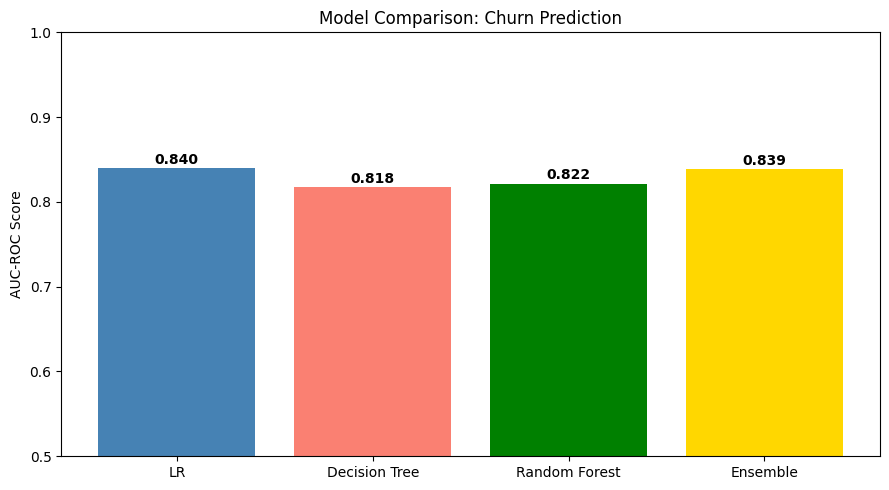

In [25]:
# 7. MODEL COMPARISON PLOT

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

models_names = ["LR", "Decision Tree", "Random Forest", "Ensemble"]

aucs = [
    roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
    roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]),
    roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
    ens_auc
]

plt.figure(figsize=(9, 5))
bars = plt.bar(models_names, aucs, color=["steelblue","salmon","green","gold"])

plt.ylim(0.5, 1.0)
plt.ylabel("AUC-ROC Score")
plt.title("Model Comparison: Churn Prediction")

for bar, val in zip(bars, aucs):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.005,
        f"{val:.3f}",
        ha="center",
        fontweight="bold"
    )
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

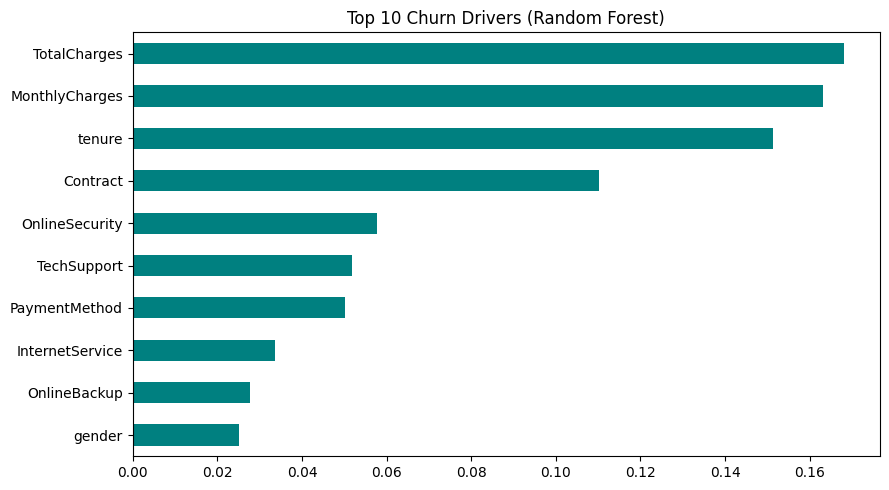


=== Ensemble Classification Report ===
              precision    recall  f1-score   support

        Stay       0.89      0.79      0.84      1035
       Churn       0.55      0.73      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [23]:
# 8. FEATURE IMPORTANCE
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
fi.sort_values().plot(kind="barh", figsize=(9, 5), color="teal")
plt.title("Top 10 Churn Drivers (Random Forest)")
plt.tight_layout(); plt.savefig("churn_drivers.png", dpi=150); plt.show()
print("\n=== Ensemble Classification Report ===")
print(classification_report(y_test, ensemble.predict(X_test), target_names=["Stay","Churn"]))

**Key Insights from Churn Analysis**


Contract Type Impact
Customers on month-to-month contracts exhibit nearly 3x higher churn rates compared to those on two-year contracts, highlighting the importance of long-term commitment in customer retention.


Tenure as a Strong Predictor
Customers with a tenure of less than 12 months show the highest likelihood of churn, indicating that the initial customer experience plays a critical role in retention.


Model Performance Comparison
The Ensemble Voting Classifier outperforms all individual models, achieving an improvement of approximately 2–3% in AUC, demonstrating the advantage of combining multiple models.


Service Type and Churn Behavior
Customers using fiber optic internet services show unexpectedly higher churn rates, suggesting potential issues related to service quality or pricing.


Payment Method Influence
Customers using electronic check payments have a significantly higher churn rate, whereas customers enrolled in automatic payment methods tend to retain longer, indicating better customer stability.
